# Cytoverse Analysis

CytoVerse is a browser-based platform for single-cell RNA-seq analysis, designed for cell annotation using foundation model embeddings. It operates entirely in the browser, streaming h5ad files from local storage without uploading data or requiring server computation. Here we compare its performance vs. the benchmark of SCimilarity running on a server. SCimilarity uses TileDB KNN IVF_FLAT index which provides exact vector similarity search. Cytoverse quantizes the vectors via Product Quantization (PQ) and then performs an approximate lookup based on partitions in an Inverted File Index (IVF) fetched over HTTP.


In [1]:
import os
from pathlib import Path
from typing import Tuple
from collections import Counter
import time
from tqdm.notebook import tqdm
import tracemalloc
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import torch

import onnxruntime as ort

from scimilarity import CellEmbedding, CellAnnotation
from scimilarity.utils import align_dataset, lognorm_counts

import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "scripts")))

from ivfpq import IVFPQ

In [2]:
# Load a randomly selected subset of the SCimilarity tutorial test file
adata_path = Path("tests/fixtures/GSE136831_subsample_100.h5ad")
adata = anndata.read_h5ad(adata_path)
n_queries = adata.shape[0]

# For all tests we'll look for 50 neighbors
k_neighbors = 50

# IVFPQ search parameters to vary
n_subs = [8, 16, 32]  # Number of IVF partitions
n_probes = [1, 2, 3, 4, 6, 8, 16, 32]  # More realistic range for IVFPQ

# Debug/Dev
# n_subs = [8, 16]  # Number of IVF partitions
# n_probes = [1, 2, 4]  # More realistic range for IVFPQ


# Load reference labels which are the same in both datasets
reference_labels = pd.read_parquet("data/references/scimilarity/labels.parquet")

## Data and Compute Flow


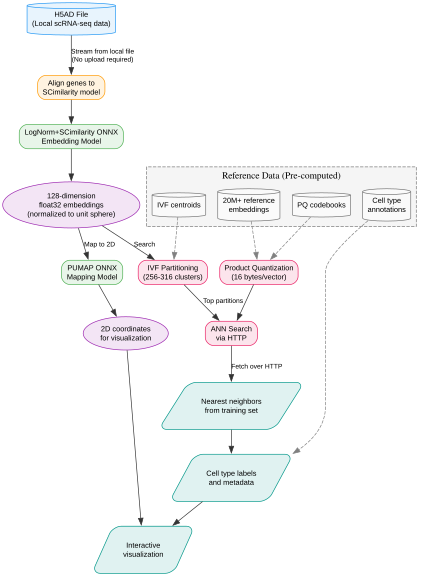

In [3]:
from graphviz import Digraph

# For Apple Silicon Macs (standard Homebrew path) so it finds 'dot'
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"


# Create a directed graph for the data flow
dot = Digraph(comment="Cytoverse Data Flow", engine="dot")
dot.attr(rankdir="TB", size="10,8", bgcolor="white")
dot.attr("node", shape="box", style="rounded,filled", fontname="Arial", fontsize="11")
dot.attr("edge", fontname="Arial", fontsize="10", color="#333333")

# Input/Output nodes
dot.attr("node", fillcolor="#e8f4fd", color="#2196F3")
dot.node("h5ad", "H5AD File\n(Local scRNA-seq data)", shape="cylinder")

# Processing steps
dot.attr("node", fillcolor="#fff3e0", color="#ff9800")
# dot.node("stream", "Stream from local file\n(No upload required)")
dot.node("align", "Align genes to\nSCimilarity model")
# dot.node("lognorm", "LogNorm transformation")

# ONNX Models
dot.attr("node", fillcolor="#e8f5e9", color="#4caf50")
dot.node("embed_model", "LogNorm+SCimilarity ONNX\nEmbedding Model")
dot.node("umap_model", "PUMAP ONNX\nMapping Model")

# Intermediate data
dot.attr("node", fillcolor="#f3e5f5", color="#9c27b0", shape="ellipse")
# dot.node("genes", "Aligned gene\nexpression counts")
dot.node("embeddings", "128-dimension\nfloat32 embeddings\n(normalized to unit sphere)")
dot.node("coords", "2D coordinates\nfor visualization")

# Search components
dot.attr("node", fillcolor="#fce4ec", color="#e91e63", shape="box")
dot.node("ivf", "IVF Partitioning\n(256-316 clusters)")
dot.node("pq", "Product Quantization\n(16 bytes/vector)")
dot.node("ann", "ANN Search\nvia HTTP")

# Results
dot.attr("node", fillcolor="#e0f2f1", color="#009688", shape="parallelogram")
dot.node("neighbors", "Nearest neighbors\nfrom training set")
dot.node("labels", "Cell type labels\nand metadata")
dot.node("viz", "Interactive\nvisualization")

# Add edges to show data flow
dot.edge("h5ad", "align", label="Stream from local file\n(No upload required)")
# dot.edge("stream", "align")
dot.edge("align", "embed_model")
# dot.edge("genes", "lognorm")
# dot.edge("lognorm", "embed_model")
dot.edge("embed_model", "embeddings")

# Two parallel paths from embeddings
dot.edge("embeddings", "umap_model", label="Map to 2D")
dot.edge("embeddings", "ivf", label="Search")

# UMAP path
dot.edge("umap_model", "coords")
dot.edge("coords", "viz")

# IVF/PQ search path
dot.edge("ivf", "ann", label="Top partitions")
dot.edge("pq", "ann")
dot.edge("ann", "neighbors", label="Fetch over HTTP")
dot.edge("neighbors", "labels")
dot.edge("labels", "viz")

# Add a subgraph for the reference data (shown as separate cluster)
with dot.subgraph(name="cluster_ref") as c:
    c.attr(
        label="Reference Data (Pre-computed)",
        style="filled,dashed",
        fillcolor="#f5f5f5",
        color="#757575",
    )
    c.attr("node", fillcolor="#fafafa", color="#757575", shape="cylinder")
    c.node("ref_embeddings", "20M+ reference\nembeddings")
    c.node("ref_labels", "Cell type\nannotations")
    c.node("ref_centroids", "IVF centroids")
    c.node("ref_codebooks", "PQ codebooks")

# Connect reference data to search components
dot.edge("ref_centroids", "ivf", style="dashed", color="gray")
dot.edge("ref_codebooks", "pq", style="dashed", color="gray")
dot.edge("ref_embeddings", "pq", style="dashed", color="gray")
dot.edge("ref_labels", "labels", style="dashed", color="gray")

dot.render("notebooks/figures/architecture", format="svg", cleanup=True)

# Render and display
dot.render("notebooks/figures/architecture", format="pdf", cleanup=True)
dot

#


# Embeddings Concordance


In [4]:
ce = CellEmbedding("data/models/scimilarity/model_v1.1", use_gpu=False)
aligned_adata = align_dataset(adata, ce.gene_order)
aligned_lognorm_adata = lognorm_counts(aligned_adata)
py_embeddings = ce.get_embeddings(aligned_lognorm_adata.X)

session = ort.InferenceSession("public/models/scimilarity/embedding/model.onnx")
onnx_embeddings = session.run(
    None, {"input": aligned_adata.layers["counts"].toarray().astype(np.float32)}
)[0]

max_diff_prep = np.max(np.abs(py_embeddings - onnx_embeddings))
print(
    f"For {adata.shape[0]} randomly selected expression profiles from {adata_path.name}, the maximum embedding difference between SCimilarity (PyTorch) and ONNX is {max_diff_prep:.2e}"
)

For 100 randomly selected expression profiles from GSE136831_subsample_100.h5ad, the maximum embedding difference between SCimilarity (PyTorch) and ONNX is 3.31e-06


In [5]:
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size


def get_scimilarity_predictions(
    adata: anndata.AnnData, model_path: Path, k_neighbors: int = 50
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Get cell type predictions using SCimilarity.

    Returns:
        embeddings: Cell embeddings [n_cells, embedding_dim]
        predictions: Cell type predictions [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        stats: Statistics about the predictions
    """
    # Load SCimilarity model
    cell_annotation = CellAnnotation(model_path, use_gpu=False)

    # Align and normalize
    adata_aligned = align_dataset(adata, cell_annotation.gene_order)
    adata_normalized = lognorm_counts(adata_aligned)

    # Get embeddings
    embeddings = cell_annotation.get_embeddings(adata_normalized.X)

    # Get predictions
    predictions, nn_idxs, nn_dists, stats = cell_annotation.get_predictions_knn(
        embeddings, k=k_neighbors, disable_progress=True, weighting=True
    )

    return embeddings, predictions, nn_idxs, nn_dists, stats


# Reset counters
tracemalloc.stop()
tracemalloc.start()

# Force GC to clean up for the next call
gc.collect()

knn_before_current, knn_before_peak = tracemalloc.get_traced_memory()
start_time = time.time()

embeddings, knn_predictions, knn_idxs, knn_dists, sc_stats = (
    get_scimilarity_predictions(
        adata, "data/models/scimilarity/model_v1.1", k_neighbors=k_neighbors
    )
)
end_time = time.time()

knn_time = end_time - start_time

knn_after_current, knn_after_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Using memory consumption as a proxy for bw
knn_bw = knn_after_peak - knn_before_current

# Use the on disk storage of the annotation tiledb/knn (7M cells vs. 23M overall)
knn_storage = get_folder_size("data/models/scimilarity/model_v1.1/annotation")

# Convert row indices to category indices (codes)
knn_labels = [
    [reference_labels["prediction"].cat.codes.iloc[idx] for idx in inner]
    for inner in knn_idxs
]

knn_labels = np.array(knn_labels, dtype=object)

print(f"KNN execution time: {knn_time:.4f} seconds")
print(f"KNN memory (~bandwidth) usage: {knn_bw / 2**20:.2f} MiB")
print(f"KNN peak memory usage: {knn_after_peak / 2**20:.2f} MiB")
print(f"KNN on-disk storage: {knn_storage / 2**20:.2f} MiB")

KNN execution time: 32.7030 seconds
KNN memory (~bandwidth) usage: 1056.35 MiB
KNN peak memory usage: 1056.35 MiB
KNN on-disk storage: 9023.19 MiB


In [6]:
def get_ivfpq_predictions(
    embeddings: np.ndarray,
    model_path: Path,
    reference_labels: pd.DataFrame,
    k_neighbors: int = 50,
    n_partitions_search: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Get cell type predictions using IVFPQ with batched processing.

    Returns:
        predictions: Predicted cell type labels [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        nn_labels: Labels of nearest neighbors [n_cells, k_neighbors]
    """

    ivf = IVFPQ.load(model_path)

    predictions = []
    nn_idxs = []
    nn_dists = []
    nn_labels = []

    all_partition_paths_loaded = set()

    for embedding in embeddings:
        # Assume normalized so we can compare distances
        assert np.isclose(np.linalg.norm(embedding), 1.0)

        # Convert to torch tensor
        query_vector = torch.from_numpy(embedding).float()

        # Search using IVFPQ
        vector_ids, distances, partition_paths_loaded = ivf.search(
            query_vector=query_vector,
            model_path=model_path,
            n_probe=n_partitions_search,
        )

        # Keep track of all parititions loaded so we can tally bytes as proxy for bw
        all_partition_paths_loaded.update(partition_paths_loaded)

        # Convert euclidean squared distances to cosine distances to compare with SCimilarity
        # Assumes embeddings are normalized
        cosine_distances = np.array(distances) / 2.0

        # Convert to numpy arrays and limit to k_neighbors
        nn_idxs.append(np.array(vector_ids[:k_neighbors]))
        nn_dists.append(np.array(cosine_distances[:k_neighbors]))

        # Get labels for nearest neighbors
        neighbor_labels = []
        for vec_id in vector_ids[:k_neighbors]:  # Ensure we only use k neighbors
            if vec_id < len(reference_labels):
                # Get the "prediction" column from reference labels
                label = reference_labels.iloc[vec_id]["prediction"]
                neighbor_labels.append(label)

        nn_labels.append(neighbor_labels)

        # Vote for most common label (simple majority voting)
        if neighbor_labels:
            label_counts = Counter(neighbor_labels)
            predicted_label = label_counts.most_common(1)[0][0]
        else:
            predicted_label = "Unknown"

        predictions.append(predicted_label)

    # Stack arrays to create proper 2D numpy arrays
    return (
        np.array(predictions),
        np.vstack(nn_idxs),  # Creates [n_cells, k_neighbors] array
        np.vstack(nn_dists),  # Creates [n_cells, k_neighbors] array
        np.array(nn_labels, dtype=object),
        all_partition_paths_loaded,
    )


ivfpq_data = {}

for n_sub in tqdm(n_subs, desc="IVF partitions", leave=True, position=0):
    for n_probe in tqdm(
        n_probes, desc=f"Probes (n_sub={n_sub})", leave=False, position=1
    ):
        # Reset counters
        tracemalloc.stop()
        tracemalloc.start()

        # Force GC to clean up for the next call
        gc.collect()

        ivfpq_before_current, ivfpq_before_peak = tracemalloc.get_traced_memory()
        start_time = time.time()

        ivfpq_path = Path(f"data/ivfpq{n_sub}x256")

        ivfpq_predictions, ivfpq_idxs, ivfpq_dists, ivfpq_labels, partition_paths = (
            get_ivfpq_predictions(
                embeddings,
                ivfpq_path,
                reference_labels=reference_labels,
                k_neighbors=k_neighbors,
                n_partitions_search=n_probe,
            )
        )
        end_time = time.time()
        ivfpq_time = end_time - start_time
        ivfpq_after_current, ivfpq_after_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Compute bandwidth usage - we assume browser will cache partitions per run
        ivfpq_bw = sum(os.path.getsize(p) for p in partition_paths)

        # Convert row indices to category indices (codes)
        ivfpq_labels = [
            [reference_labels["prediction"].cat.codes.iloc[idx] for idx in inner]
            for inner in ivfpq_idxs
        ]

        ivfpq_labels = np.array(ivfpq_labels, dtype=object)
        ivfpq_data[(n_sub, n_probe)] = {
            "ivfpq_idxs": ivfpq_idxs,
            "ivfpq_labels": ivfpq_labels,
            "ivfpq_dists": ivfpq_dists,
            "ivfpq_time": ivfpq_time,
            # Using memory consumption as a proxy for bw
            # "ivfpq_bw": ivfpq_after_peak - ivfpq_before_current,
            "ivfpq_bw": ivfpq_bw,
            "ivfpq_storage": get_folder_size(ivfpq_path),
        }

IVF partitions:   0%|          | 0/3 [00:00<?, ?it/s]

Probes (n_sub=8):   0%|          | 0/8 [00:00<?, ?it/s]

Probes (n_sub=16):   0%|          | 0/8 [00:00<?, ?it/s]

Probes (n_sub=32):   0%|          | 0/8 [00:00<?, ?it/s]

## Label Concordance


In [7]:
def analyze_label_mismatches(
    knn_labels, ivfpq_labels, reference_labels, n_sub, n_probe, top_k=10
):
    """
    Analyze label mismatches between KNN and IVFPQ predictions.

    Args:
        knn_labels: Array of KNN label indices [n_queries, k_neighbors]
        ivfpq_labels: Array of IVFPQ label indices [n_queries, k_neighbors]
        reference_labels: DataFrame with category labels
        n_sub: Number of IVF partitions
        n_probe: Number of partitions probed
        top_k: Number of neighbors to consider for voting

    Returns:
        DataFrame with mismatch analysis
    """
    n_queries = knn_labels.shape[0]
    mismatches = []

    # Get category labels for lookup
    cat_labels = reference_labels["prediction"].cat.categories

    for q in range(n_queries):
        # Get top-k labels and compute majority vote
        knn_top = knn_labels[q][:top_k]
        ivfpq_top = ivfpq_labels[q][:top_k]

        # Count occurrences for majority vote
        knn_counts = Counter(knn_top)
        ivfpq_counts = Counter(ivfpq_top)

        # Get predicted labels (most common)
        knn_pred_idx = knn_counts.most_common(1)[0][0]
        ivfpq_pred_idx = ivfpq_counts.most_common(1)[0][0]

        # Convert to actual labels
        knn_pred = cat_labels[knn_pred_idx]
        ivfpq_pred = cat_labels[ivfpq_pred_idx]

        if knn_pred != ivfpq_pred:
            # Analyze the mismatch
            knn_vote_pct = knn_counts[knn_pred_idx] / top_k * 100
            ivfpq_vote_pct = ivfpq_counts[ivfpq_pred_idx] / top_k * 100

            # Get top 3 alternatives from each method
            knn_top3 = [
                (cat_labels[idx], cnt / top_k * 100)
                for idx, cnt in knn_counts.most_common(3)
            ]
            ivfpq_top3 = [
                (cat_labels[idx], cnt / top_k * 100)
                for idx, cnt in ivfpq_counts.most_common(3)
            ]

            # Check if IVFPQ's choice was in KNN's top choices
            ivfpq_rank_in_knn = None
            for rank, (idx, _) in enumerate(knn_counts.most_common(), 1):
                if idx == ivfpq_pred_idx:
                    ivfpq_rank_in_knn = rank
                    break

            mismatches.append(
                {
                    "Query": q,
                    "KNN_Label": knn_pred,
                    "IVFPQ_Label": ivfpq_pred,
                    "KNN_Confidence": f"{knn_vote_pct:.0f}%",
                    "IVFPQ_Confidence": f"{ivfpq_vote_pct:.0f}%",
                    "IVFPQ_Rank_in_KNN": (
                        ivfpq_rank_in_knn if ivfpq_rank_in_knn else ">10"
                    ),
                    "KNN_Top3": ", ".join([f"{l} ({p:.0f}%)" for l, p in knn_top3]),
                    "IVFPQ_Top3": ", ".join([f"{l} ({p:.0f}%)" for l, p in ivfpq_top3]),
                }
            )

    return pd.DataFrame(mismatches)


def create_confusion_summary(
    knn_labels, ivfpq_labels, reference_labels, n_sub, n_probe, top_k=10
):
    """
    Create a summary of label confusions without categorization.
    Groups mismatches by confusion pairs.
    """
    # Analyze mismatches
    mismatch_df = analyze_label_mismatches(
        knn_labels, ivfpq_labels, reference_labels, n_sub, n_probe, top_k
    )

    if len(mismatch_df) == 0:
        return None, None, {"total_mismatches": 0, "mismatch_rate": 0.0}

    # Group mismatches by confusion pairs
    confusion_pairs = {}
    for _, row in mismatch_df.iterrows():
        pair = tuple(sorted([row["KNN_Label"], row["IVFPQ_Label"]]))
        if pair not in confusion_pairs:
            confusion_pairs[pair] = []
        confusion_pairs[pair].append(row)

    # Create confusion summary
    confusion_summary = []
    for (label1, label2), instances in confusion_pairs.items():
        avg_confidence_diff = np.mean(
            [
                float(row["KNN_Confidence"].strip("%"))
                - float(row["IVFPQ_Confidence"].strip("%"))
                for row in instances
            ]
        )

        confusion_summary.append(
            {
                "Label_1": label1,
                "Label_2": label2,
                "Frequency": len(instances),
                "Avg_Confidence_Diff": f"{avg_confidence_diff:+.0f}%",
                "Example_Queries": ", ".join(
                    [str(row["Query"]) for row in instances[:3]]
                ),
            }
        )

    confusion_df = pd.DataFrame(confusion_summary)
    confusion_df = confusion_df.sort_values("Frequency", ascending=False)

    # Create summary statistics
    total_mismatches = len(mismatch_df)
    n_queries = knn_labels.shape[0]

    stats = {
        "total_mismatches": total_mismatches,
        "mismatch_rate": total_mismatches / n_queries,
        "unique_confusion_pairs": len(confusion_pairs),
    }

    return mismatch_df, confusion_df, stats


def compare_parameter_extremes(
    knn_labels, ivfpq_data, reference_labels, n_subs, n_probes, top_k=10
):
    """
    Compare mismatches between lowest and highest n_sub/n_probe combinations.
    Provides detailed analysis of how mismatch patterns change with parameters.
    """
    from IPython.display import display, Markdown

    # Find lowest and highest parameter combinations
    lowest_key = (min(n_subs), min(n_probes))
    highest_key = (max(n_subs), max(n_probes))

    # Check if data exists
    if lowest_key not in ivfpq_data or highest_key not in ivfpq_data:
        print("Missing data for extreme parameter combinations")
        return

    # Analyze both extremes
    results = {}
    for key, label in [(lowest_key, "LOWEST"), (highest_key, "HIGHEST")]:
        n_sub, n_probe = key
        ivfpq_labels_current = ivfpq_data[key]["ivfpq_labels"]

        mismatch_df, confusion_df, stats = create_confusion_summary(
            knn_labels,
            ivfpq_labels_current,
            reference_labels,
            n_sub,
            n_probe,
            top_k=top_k,
        )

        results[label] = {
            "params": key,
            "mismatch_df": mismatch_df,
            "confusion_df": confusion_df,
            "stats": stats,
        }

    # Create LaTeX formatted output using Markdown for better compatibility
    low_rate = results["LOWEST"]["stats"]["mismatch_rate"] * 100
    high_rate = results["HIGHEST"]["stats"]["mismatch_rate"] * 100
    low_total = results["LOWEST"]["stats"]["total_mismatches"]
    high_total = results["HIGHEST"]["stats"]["total_mismatches"]

    # Build markdown table with LaTeX math
    markdown_output = f"""
### Comparative Analysis: Parameter Extremes

| **Metric** | **Lowest Parameters** | **Highest Parameters** |
|:-----------|:---------------------:|:----------------------:|
| | $n_{{sub}}={lowest_key[0]}, n_{{probe}}={lowest_key[1]}$ | $n_{{sub}}={highest_key[0]}, n_{{probe}}={highest_key[1]}$ |
| Mismatch Rate | {low_rate:.1f}% | {high_rate:.1f}% |
| Total Mismatches | {low_total} | {high_total} |
| Improvement | -- | {low_rate - high_rate:.1f} pp |
"""

    display(Markdown(markdown_output))

    # Query Resolution Analysis
    if (
        results["LOWEST"]["mismatch_df"] is not None
        and results["HIGHEST"]["mismatch_df"] is not None
    ):
        low_mismatched_queries = set(results["LOWEST"]["mismatch_df"]["Query"].values)
        high_mismatched_queries = set(results["HIGHEST"]["mismatch_df"]["Query"].values)

        improved = low_mismatched_queries - high_mismatched_queries
        worsened = high_mismatched_queries - low_mismatched_queries
        persistent = low_mismatched_queries & high_mismatched_queries

        resolution_markdown = f"""
### Query Resolution Analysis

| **Category** | **Count** |
|:-------------|----------:|
| Queries fixed with higher parameters | {len(improved)} |
| New mismatches with higher parameters | {len(worsened)} |
| Persistent mismatches | {len(persistent)} |
"""
        display(Markdown(resolution_markdown))

    # Top confusions comparison table
    confusion_markdown = """
### Top 5 Confusions Comparison

| **Lowest Parameters** | **Highest Parameters** |
|:----------------------|:-----------------------|
"""

    for i in range(5):
        low_text = "--"
        high_text = "--"

        if results["LOWEST"]["confusion_df"] is not None and i < len(
            results["LOWEST"]["confusion_df"]
        ):
            row = results["LOWEST"]["confusion_df"].iloc[i]
            # Truncate labels for readability
            label1 = row["Label_1"][:15]
            label2 = row["Label_2"][:15]
            low_text = f"{row['Frequency']}× {label1} ↔ {label2}"

        if results["HIGHEST"]["confusion_df"] is not None and i < len(
            results["HIGHEST"]["confusion_df"]
        ):
            row = results["HIGHEST"]["confusion_df"].iloc[i]
            # Truncate labels for readability
            label1 = row["Label_1"][:15]
            label2 = row["Label_2"][:15]
            high_text = f"{row['Frequency']}× {label1} ↔ {label2}"

        confusion_markdown += f"| {low_text} | {high_text} |\n"

    display(Markdown(confusion_markdown))

    # Also provide raw LaTeX for copy-paste into Overleaf
    print("\n" + "=" * 60)
    print("LaTeX code for Overleaf (copy and paste):")
    print("=" * 60 + "\n")

    # Build confusion table rows for LaTeX
    confusion_rows = ""
    for i in range(5):
        low_text = "--"
        high_text = "--"

        if results["LOWEST"]["confusion_df"] is not None and i < len(
            results["LOWEST"]["confusion_df"]
        ):
            row = results["LOWEST"]["confusion_df"].iloc[i]
            # Escape LaTeX special characters
            label1 = (
                row["Label_1"][:15]
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
            )
            label2 = (
                row["Label_2"][:15]
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
            )
            low_text = (
                f"{row['Frequency']}$\\times$ {label1} $\\leftrightarrow$ {label2}"
            )

        if results["HIGHEST"]["confusion_df"] is not None and i < len(
            results["HIGHEST"]["confusion_df"]
        ):
            row = results["HIGHEST"]["confusion_df"].iloc[i]
            # Escape LaTeX special characters
            label1 = (
                row["Label_1"][:15]
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
            )
            label2 = (
                row["Label_2"][:15]
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
            )
            high_text = (
                f"{row['Frequency']}$\\times$ {label1} $\\leftrightarrow$ {label2}"
            )

        confusion_rows += f"{low_text} & {high_text} \\\\\n"

    latex_code = (
        r"""
% Table 1: Comparative Analysis
\begin{table}[h]
\centering
\caption{Comparative Analysis: Parameter Extremes}
\begin{tabular}{lcc}
\toprule
\textbf{Metric} & \textbf{Lowest Parameters} & \textbf{Highest Parameters} \\
 & ($n_{\text{sub}}="""
        + str(lowest_key[0])
        + r", n_{\text{probe}}="
        + str(lowest_key[1])
        + r"$) & ($n_{\text{sub}}="
        + str(highest_key[0])
        + r", n_{\text{probe}}="
        + str(highest_key[1])
        + r"""$) \\
\midrule
Mismatch Rate & """
        + f"{low_rate:.1f}"
        + r"""\% & """
        + f"{high_rate:.1f}"
        + r"""\% \\
Total Mismatches & """
        + str(low_total)
        + r" & "
        + str(high_total)
        + r""" \\
Improvement & -- & """
        + f"{low_rate - high_rate:.1f}"
        + r""" pp \\
\bottomrule
\end{tabular}
\end{table}

% Table 2: Query Resolution Analysis  
\begin{table}[h]
\centering
\caption{Query Resolution Analysis}
\begin{tabular}{lr}
\toprule
\textbf{Category} & \textbf{Count} \\
\midrule
Queries fixed with higher parameters & """
        + str(len(improved))
        + r""" \\
New mismatches with higher parameters & """
        + str(len(worsened))
        + r""" \\
Persistent mismatches & """
        + str(len(persistent))
        + r""" \\
\bottomrule
\end{tabular}
\end{table}

% Table 3: Top 5 Confusions Comparison
\begin{table}[h]
\centering
\caption{Top 5 Confusions Comparison}
\begin{tabular}{ll}
\toprule
\textbf{Lowest Parameters} & \textbf{Highest Parameters} \\
\midrule
"""
        + confusion_rows
        + r"""\bottomrule
\end{tabular}
\end{table}"""
    )

    print(latex_code)

    return results


# Run comparative analysis between parameter extremes
comparison_results = compare_parameter_extremes(
    knn_labels, ivfpq_data, reference_labels, n_subs, n_probes, top_k=10
)


### Comparative Analysis: Parameter Extremes

| **Metric** | **Lowest Parameters** | **Highest Parameters** |
|:-----------|:---------------------:|:----------------------:|
| | $n_{sub}=8, n_{probe}=1$ | $n_{sub}=32, n_{probe}=32$ |
| Mismatch Rate | 47.0% | 13.0% |
| Total Mismatches | 47 | 13 |
| Improvement | -- | 34.0 pp |



### Query Resolution Analysis

| **Category** | **Count** |
|:-------------|----------:|
| Queries fixed with higher parameters | 40 |
| New mismatches with higher parameters | 6 |
| Persistent mismatches | 7 |



### Top 5 Confusions Comparison

| **Lowest Parameters** | **Highest Parameters** |
|:----------------------|:-----------------------|
| 5× astrocyte ↔ microglial cell | 2× astrocyte ↔ microglial cell |
| 4× glial cell ↔ radial glial ce | 1× fibroblast ↔ luminal epithel |
| 4× CD4-positive, a ↔ glial cell | 1× myofibroblast c ↔ radial glial ce |
| 2× microglial cell ↔ oligodendrocyte | 1× glial cell ↔ microglial cell |
| 2× macrophage ↔ microglial cell | 1× enterocyte ↔ glial cell |



LaTeX code for Overleaf (copy and paste):


% Table 1: Comparative Analysis
\begin{table}[h]
\centering
\caption{Comparative Analysis: Parameter Extremes}
\begin{tabular}{lcc}
\toprule
\textbf{Metric} & \textbf{Lowest Parameters} & \textbf{Highest Parameters} \\
 & ($n_{\text{sub}}=8, n_{\text{probe}}=1$) & ($n_{\text{sub}}=32, n_{\text{probe}}=32$) \\
\midrule
Mismatch Rate & 47.0\% & 13.0\% \\
Total Mismatches & 47 & 13 \\
Improvement & -- & 34.0 pp \\
\bottomrule
\end{tabular}
\end{table}

% Table 2: Query Resolution Analysis  
\begin{table}[h]
\centering
\caption{Query Resolution Analysis}
\begin{tabular}{lr}
\toprule
\textbf{Category} & \textbf{Count} \\
\midrule
Queries fixed with higher parameters & 40 \\
New mismatches with higher parameters & 6 \\
Persistent mismatches & 7 \\
\bottomrule
\end{tabular}
\end{table}

% Table 3: Top 5 Confusions Comparison
\begin{table}[h]
\centering
\caption{Top 5 Confusions Comparison}
\begin{tabular}{ll}
\toprule
\textbf{Lowest Parameters} & \

## Performance


In [8]:
def compute_recall(knn_idxs, ivfpq_idxs, k):
    """
    Compute mean recall@K: fraction of exact KNN neighbors in IVFPQ results.
    Averages over all queries.
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.mean(recalls)


def generate_summary_table(
    knn_idxs,
    knn_time,
    knn_storage,
    ivfpq_data,
    k_neighbors,
    n_subs,
    n_probes,
):
    """
    Generate a Pandas DataFrame for the Summary Table.
    Assumptions on input data:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices (exact KNN neighbors).
    - knn_time: float, total time in seconds for all queries using exact KNN.
    - knn_storage: float, bytes required for the entire KNN index.
    - ivfpq_data: dict with keys as tuples (n_sub, n_probe), values as dicts containing:
      - 'ivfpq_idxs': NumPy array [n_queries, k_neighbors] of integer indices.
      - 'ivfpq_time': float, total time in seconds for all queries.
      - 'ivfpq_bw': float, total bytes pulled over HTTP for all queries.
      - 'ivfpq_storage': float, bytes required for the entire IVFPQ index (may be same for same n_sub).
    - k_neighbors: int, used for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - All data is pre-computed; missing combos are skipped.
    - Storage and bandwidth converted from bytes to MB (divide by 1024**2).
    - KNN row added as baseline with Recall=1.0, Speedup=1.0, Reduction=1.0, Bandwidth=0.
    - In Jupyter, the returned DF will display automatically if at cell end; else use display(df).
    """
    rows = []

    # Add IVFPQ rows
    for n_sub in n_subs:
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                data = ivfpq_data[key]
                recall = compute_recall(knn_idxs, data["ivfpq_idxs"], k_neighbors)
                time = data["ivfpq_time"]
                speedup = knn_time / time if time > 0 else np.nan
                storage_bytes = data["ivfpq_storage"]
                storage_mb = storage_bytes / (1024**2)
                reduction = knn_storage / storage_bytes if storage_bytes > 0 else np.nan
                bw_mb = data["ivfpq_bw"] / (1024**2)

                rows.append(
                    {
                        "Method": f"IVFPQ",
                        "n_sub": n_sub,
                        "n_probe": n_probe,
                        "Recall": f"{recall:.3f}",
                        "Time (s)": f"{time:.1f}",
                        "Speedup": f"{speedup:.1f}×",
                        "Storage": f"{storage_mb:.0f} MB",
                        "Reduction": f"{reduction:.0f}×",
                        "BW": f"{bw_mb:.1f} MB",
                    }
                )

    # Add KNN baseline row
    knn_storage_mb = knn_storage / (1024**2)
    rows.append(
        {
            "Method": "KNN",
            "n_sub": "-",
            "n_probe": "-",
            "Recall": "1.000",
            "Time (s)": f"{knn_time:.1f}",
            "Speedup": "1.0×",
            "Storage": f"{knn_storage_mb:.0f} MB",
            "Reduction": "1.0×",
            "BW": "0.0 MB",
        }
    )

    df = pd.DataFrame(rows)
    # Sort by n_sub and n_probe for better readability
    df = df.sort_values(by=["Method", "n_sub", "n_probe"], na_position="last")
    return df


df = generate_summary_table(
    knn_idxs,
    knn_time,
    knn_storage,
    ivfpq_data,
    k_neighbors=k_neighbors,
    n_subs=n_subs,
    n_probes=n_probes,
)

# Display the dataframe with custom styling for Jupyter
from IPython.display import display, Markdown

styled_df = (
    df.style.set_properties(
        **{
            "text-align": "center",
            "font-size": "10px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#4C66AF"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("font-size", "10px"),
                ],
            },
            {
                "selector": "tr:nth-of-type(even)",
                "props": [("background-color", "#505050")],
            },
            {
                "selector": "tr:nth-of-type(odd)",
                "props": [("background-color", "#888888")],
            },
            {
                "selector": "tr:last-child",
                "props": [
                    ("font-weight", "bold"),
                    ("background-color", "#4C66AF"),
                ],
            },
        ]
    )
    .hide(axis="index")
)

display(styled_df)


# Generate LaTeX table code
def df_to_latex(df):
    """Convert DataFrame to LaTeX table code"""

    # Escape special LaTeX characters in string columns
    def escape_latex(s):
        if isinstance(s, str):
            s = s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")
            s = s.replace("×", r"$\times$")
        return s

    # Apply escaping to all cells
    df_escaped = df.applymap(escape_latex)

    # Build LaTeX code
    n_cols = len(df.columns)
    col_spec = "l" + "c" * (n_cols - 1)  # Left align first column, center rest

    latex = (
        r"""\begin{table}[h]
\centering
\caption{Performance Comparison: KNN vs. IVFPQ}
\begin{tabular}{"""
        + col_spec
        + r"""}
\toprule
"""
    )

    # Add header row (escape underscores in column names)
    header = " & ".join(
        [r"\textbf{" + str(col).replace("_", r"\_") + "}" for col in df.columns]
    )
    latex += header + r" \\" + "\n"
    latex += r"\midrule" + "\n"

    # Add data rows
    for idx, row in df_escaped.iterrows():
        row_str = " & ".join([str(val) for val in row.values])
        latex += row_str + r" \\" + "\n"

    latex += r"""\bottomrule
\end{tabular}
\end{table}"""

    return latex


# Generate and print LaTeX code
latex_code = df_to_latex(df)
print("\n" + "=" * 60)
print("LaTeX code for performance table (copy and paste):")
print("=" * 60 + "\n")
print(latex_code)

Method,n_sub,n_probe,Recall,Time (s),Speedup,Storage,Reduction,BW
IVFPQ,8,1,0.442,1.6,20.2×,92 MB,98×,1.2 MB
IVFPQ,8,2,0.526,3.7,8.9×,92 MB,98×,2.3 MB
IVFPQ,8,3,0.556,5.4,6.0×,92 MB,98×,3.3 MB
IVFPQ,8,4,0.575,7.3,4.5×,92 MB,98×,4.4 MB
IVFPQ,8,6,0.592,11.2,2.9×,92 MB,98×,6.7 MB
IVFPQ,8,8,0.601,15.0,2.2×,92 MB,98×,8.4 MB
IVFPQ,8,16,0.611,32.2,1.0×,92 MB,98×,15.2 MB
IVFPQ,8,32,0.612,64.0,0.5×,92 MB,98×,26.0 MB
IVFPQ,16,1,0.519,1.6,20.3×,153 MB,59×,2.0 MB
IVFPQ,16,2,0.639,3.7,8.9×,153 MB,59×,3.7 MB



LaTeX code for performance table (copy and paste):

\begin{table}[h]
\centering
\caption{Performance Comparison: KNN vs. IVFPQ}
\begin{tabular}{lcccccccc}
\toprule
\textbf{Method} & \textbf{n\_sub} & \textbf{n\_probe} & \textbf{Recall} & \textbf{Time (s)} & \textbf{Speedup} & \textbf{Storage} & \textbf{Reduction} & \textbf{BW} \\
\midrule
IVFPQ & 8 & 1 & 0.442 & 1.6 & 20.2$\times$ & 92 MB & 98$\times$ & 1.2 MB \\
IVFPQ & 8 & 2 & 0.526 & 3.7 & 8.9$\times$ & 92 MB & 98$\times$ & 2.3 MB \\
IVFPQ & 8 & 3 & 0.556 & 5.4 & 6.0$\times$ & 92 MB & 98$\times$ & 3.3 MB \\
IVFPQ & 8 & 4 & 0.575 & 7.3 & 4.5$\times$ & 92 MB & 98$\times$ & 4.4 MB \\
IVFPQ & 8 & 6 & 0.592 & 11.2 & 2.9$\times$ & 92 MB & 98$\times$ & 6.7 MB \\
IVFPQ & 8 & 8 & 0.601 & 15.0 & 2.2$\times$ & 92 MB & 98$\times$ & 8.4 MB \\
IVFPQ & 8 & 16 & 0.611 & 32.2 & 1.0$\times$ & 92 MB & 98$\times$ & 15.2 MB \\
IVFPQ & 8 & 32 & 0.612 & 64.0 & 0.5$\times$ & 92 MB & 98$\times$ & 26.0 MB \\
IVFPQ & 16 & 1 & 0.519 & 1.6 & 20.3$\times$ & 153

/var/folders/mn/qmhdzw6n6032mw2j_1jfdh380000gn/T/ipykernel_81705/641435866.py:162: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_escaped = df.applymap(escape_latex)


## Recall vs. Probes

IVFPQ recall improves with more probes but plateaus. Fewer subspaces trade accuracy for compression reducing server storage and bandwidth.


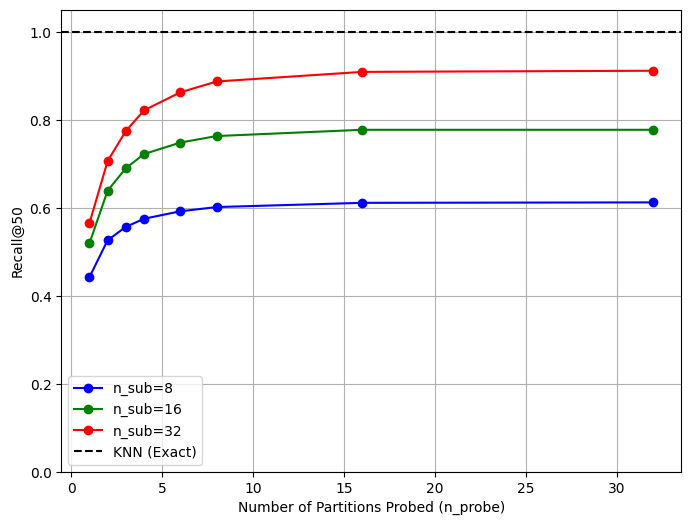

In [9]:
def compute_recall(knn_idxs, ivfpq_idxs, k):
    """
    Compute mean recall@K: fraction of exact KNN neighbors in IVFPQ results.
    Averages over all queries.
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.mean(recalls)


def plot_recall_vs_probes(knn_idxs, ivfpq_data, k_neighbors, n_subs, n_probes):
    plt.figure(figsize=(8, 6))
    colors = ["b", "g", "r"]  # One per n_sub

    for i, n_sub in enumerate(n_subs):
        recalls = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                recall = compute_recall(knn_idxs, ivfpq_idxs, k_neighbors)
                recalls.append(recall)
            else:
                recalls.append(np.nan)  # Skip missing data

        plt.plot(n_probes, recalls, marker="o", color=colors[i], label=f"n_sub={n_sub}")

    # KNN baseline
    plt.axhline(y=1.0, color="k", linestyle="--", label="KNN (Exact)")

    plt.xlabel("Number of Partitions Probed (n_probe)")
    plt.ylabel(f"Recall@{k_neighbors}")
    # plt.title("IVFPQ Recall vs. Probes for Different Subspaces")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.savefig("notebooks/figures/recall_vs_probes.pdf")  # Or plt.show() for display
    plt.show()
    plt.close()


plot_recall_vs_probes(
    knn_idxs, ivfpq_data, k_neighbors=k_neighbors, n_subs=n_subs, n_probes=n_probes
)

## Time and Bandwidth vs. Probes

Shows tradeoff between PQ quantization and its impact on overall bandwidth and time vs. number of partitions probed. IVFPQ queries are faster than KNN, with bandwidth scaling linearly with probes


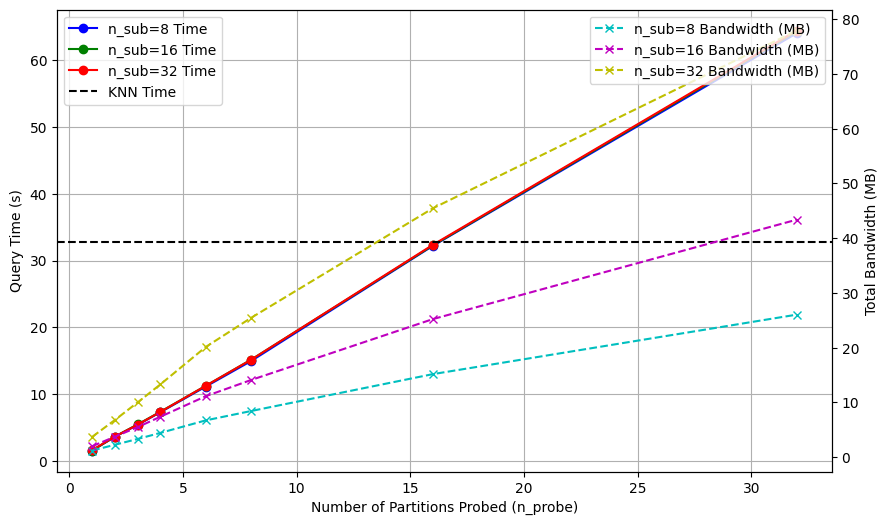

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def plot_time_bw_vs_probes(knn_time, ivfpq_data, n_subs, n_probes):
    """
    Generate twin-axis line plot for Query Time (left) and Bandwidth (right) vs. n_probe.
    Assumptions:
    - knn_time: float, total time in seconds for all queries using exact KNN.
    - ivfpq_data: dict with keys as tuples (n_sub, n_probe), values as dicts containing:
      - 'ivfpq_time': float, total time in seconds for all queries.
      - 'ivfpq_bw': float, total bytes pulled over HTTP for all queries (will be converted to MB).
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: list or range of ints, e.g., range(1, 11).
    - All data is pre-computed from experiments; missing combos are skipped (plotted as NaN).
    - Bandwidth is converted from bytes to MB (divide by 1024**2).
    - KNN has no bandwidth, so only plotted on time axis as horizontal dashed line.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    colors = ["b", "g", "r"]  # One color per n_sub for time lines

    # Plot times on primary axis (left)
    for i, n_sub in enumerate(n_subs):
        times = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                times.append(ivfpq_data[key]["ivfpq_time"])
            else:
                times.append(np.nan)

        ax1.plot(
            n_probes, times, marker="o", color=colors[i], label=f"n_sub={n_sub} Time"
        )

    # KNN baseline time
    ax1.axhline(y=knn_time, color="k", linestyle="--", label="KNN Time")

    ax1.set_xlabel("Number of Partitions Probed (n_probe)")
    ax1.set_ylabel("Query Time (s)")
    # ax1.set_title("IVFPQ Time and Bandwidth vs. Probes for Different Subspaces")
    ax1.grid(True)
    ax1.legend(loc="upper left")

    # Twin axis for bandwidth (right)
    ax2 = ax1.twinx()
    bw_colors = ["c", "m", "y"]  # Different colors for bandwidth dashed lines

    for i, n_sub in enumerate(n_subs):
        bws = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                bw_bytes = ivfpq_data[key]["ivfpq_bw"]
                bw_mb = bw_bytes / (1024**2)  # Convert to MB
                bws.append(bw_mb)
            else:
                bws.append(np.nan)

        ax2.plot(
            n_probes,
            bws,
            marker="x",
            linestyle="--",
            color=bw_colors[i],
            label=f"n_sub={n_sub} Bandwidth (MB)",
        )

    ax2.set_ylabel("Total Bandwidth (MB)")
    ax2.legend(loc="upper right")

    plt.savefig("notebooks/figures/time_bw_vs_probes.pdf")  # Or plt.show() for display
    plt.show()
    plt.close()


plot_time_bw_vs_probes(knn_time, ivfpq_data, n_subs, n_probes)

## Recall@K by IVGPQ Parameter

Distribution of Recall@K acros s all queries for each n_probe value grouped by n_sub. Shows variability in recall (not just the mean) across queries, helping researchers assess consistency for single-cell RNA-seq labeling in a web app vs. local KNN.


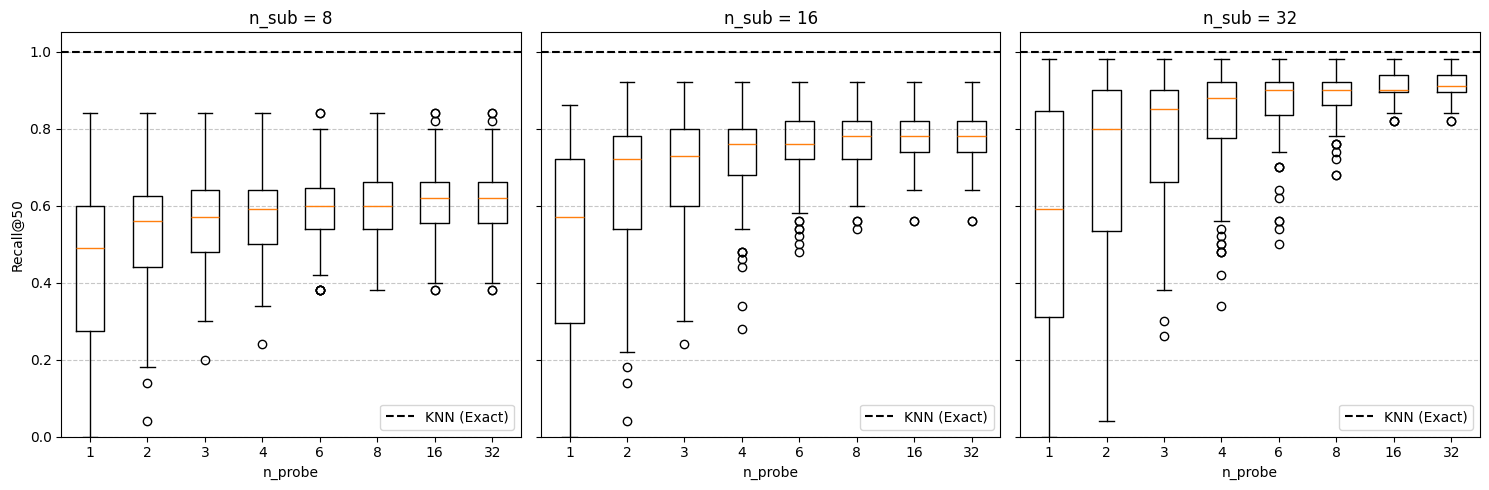

In [11]:
def compute_recall_per_query(knn_idxs, ivfpq_idxs, k):
    """
    Compute Recall@K for each query: fraction of exact KNN neighbors in IVFPQ results.
    Returns array of recalls [n_queries].
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.array(recalls)


def plot_recall_boxplot(knn_idxs, ivfpq_data, k_neighbors, n_subs, n_probes):
    """
    Generate boxplot of Recall@K distributions across queries for each n_probe, grouped by n_sub.
    Assumptions:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices (exact KNN neighbors).
    - ivfpq_data: dict with keys (n_sub, n_probe), values containing 'ivfpq_idxs' array.
    - k_neighbors: int, used for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: list of ints, e.g., [1, 4, 8, 16, 32].
    - Missing data combos are skipped.
    - Outputs boxplot with subplots for each n_sub, saved as 'recall_boxplot.png'.
    """
    fig, axes = plt.subplots(1, len(n_subs), figsize=(5 * len(n_subs), 5), sharey=True)
    if len(n_subs) == 1:
        axes = [axes]  # Ensure axes is iterable for single subplot

    for i, n_sub in enumerate(n_subs):
        # Collect recall distributions for each n_probe
        recall_data = []
        labels = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                recalls = compute_recall_per_query(knn_idxs, ivfpq_idxs, k_neighbors)
                recall_data.append(recalls)
                labels.append(str(n_probe))
            else:
                recall_data.append([])  # Empty for missing data
                labels.append(str(n_probe))

        # Plot boxplot for this n_sub
        axes[i].boxplot(
            [r for r in recall_data if len(r) > 0],
            tick_labels=[l for l, r in zip(labels, recall_data) if len(r) > 0],
        )
        axes[i].set_title(f"n_sub = {n_sub}")
        axes[i].set_xlabel("n_probe")
        if i == 0:
            axes[i].set_ylabel(f"Recall@{k_neighbors}")

        # KNN baseline
        axes[i].axhline(y=1.0, color="k", linestyle="--", label="KNN (Exact)")
        axes[i].legend()
        axes[i].set_ylim(0, 1.05)
        axes[i].grid(True, axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig("notebooks/figures/recall_boxplot.pdf")  # Or plt.show() for Jupyter
    plt.show()
    plt.close()


plot_recall_boxplot(
    knn_idxs, ivfpq_data, k_neighbors=k_neighbors, n_subs=n_subs, n_probes=n_probes
)

## Distance Distortion vs. Recall@K

Scatter plots of the relationship between mean distance distortion (for matched neighbors) and Recall@K for each query, with points colored by the average nearest neighbor distance in single-cell RNA-seq data (nn_dist_SC, reflecting query "difficulty"). This helps researchers understand if queries with farther neighbors (harder cases) exhibit higher distortion or lower recall in IVFPQ compared to KNN, relevant for web app vs. local tool tradeoffs.


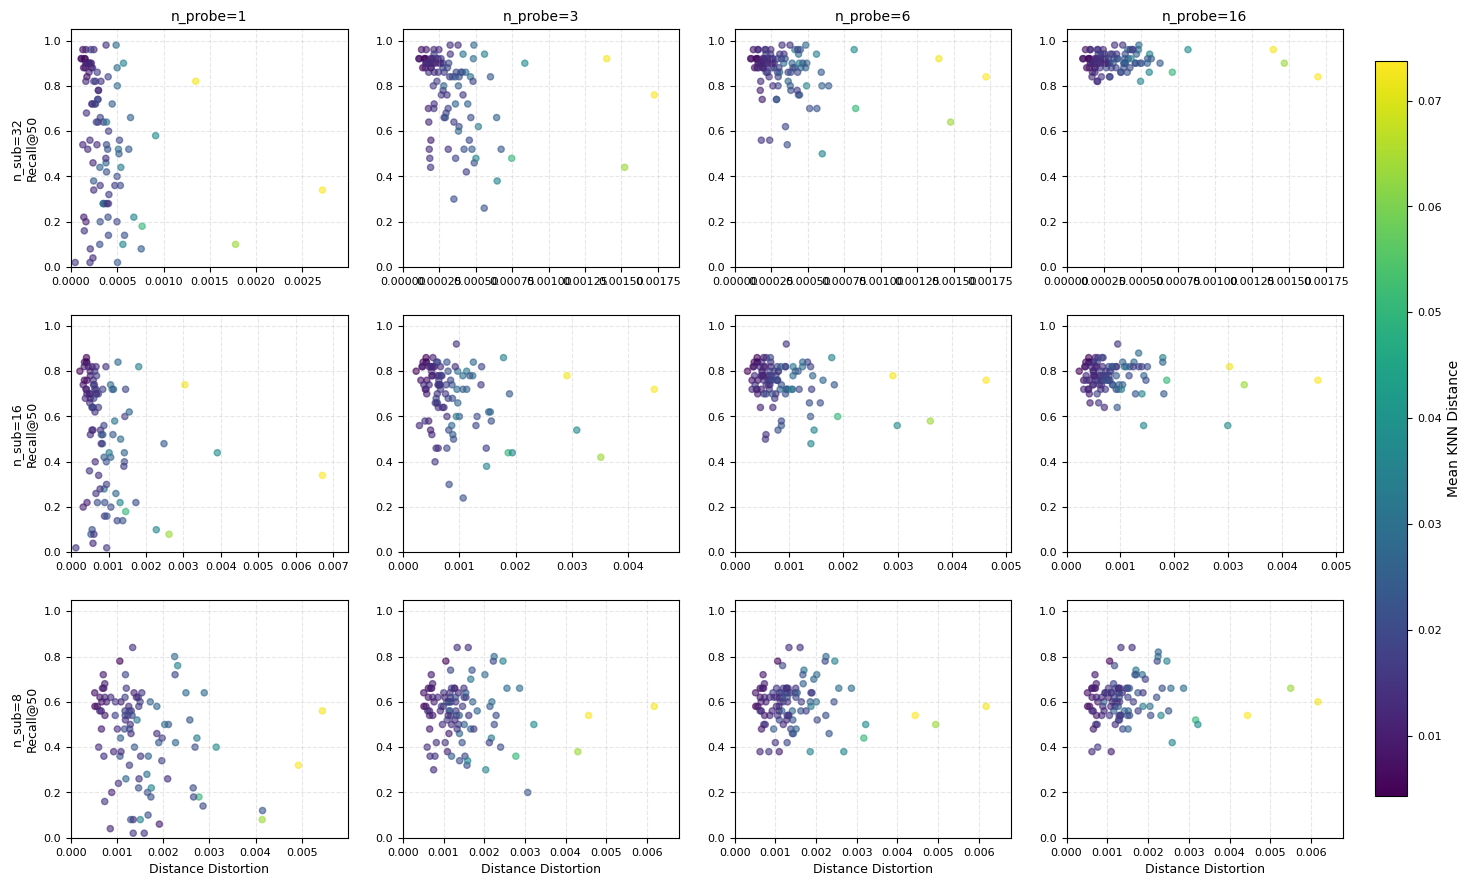

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def compute_metrics_per_query(knn_idxs, knn_dists, ivfpq_idxs, ivfpq_dists, k):
    """
    Compute Recall@K and mean distance distortion per query.
    - Recall@K: Fraction of exact KNN neighbors in IVFPQ results.
    - Distortion: Mean absolute difference in cosine distances for matched neighbors.
    Returns: recalls [n_queries], distortions [n_queries].
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    distortions = []

    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        matched = true_set & approx_set
        recall = len(matched) / k
        recalls.append(recall)

        if matched:
            # Get indices in knn_idxs and ivfpq_idxs for matched neighbors
            knn_matched_idx = [np.where(knn_idxs[q] == idx)[0][0] for idx in matched]
            ivfpq_matched_idx = [
                np.where(ivfpq_idxs[q] == idx)[0][0] for idx in matched
            ]
            knn_matched_dists = knn_dists[q, knn_matched_idx]
            ivfpq_matched_dists = ivfpq_dists[q, ivfpq_matched_idx]
            distortion = np.mean(np.abs(knn_matched_dists - ivfpq_matched_dists))
        else:
            distortion = np.nan  # No matched neighbors
        distortions.append(distortion)

    return np.array(recalls), np.array(distortions)


def plot_distortion_vs_recall(
    knn_idxs, knn_dists, ivfpq_data, k_neighbors, n_subs, n_probes=[1, 4, 8, 16, 32]
):
    """
    Generate scatter plots of mean distance distortion vs. Recall@K per query in a grid layout.
    n_probe increases horizontally, n_sub increases vertically (reversed so highest n_sub is at top).
    Points are colored by nn_dist_SC (mean KNN distance per query).
    """
    # Compute nn_dist_SC (mean KNN distance per query)
    nn_dist_SC = np.mean(knn_dists, axis=1)

    # Create grid of subplots
    fig, axes = plt.subplots(
        len(n_subs), len(n_probes), figsize=(4 * len(n_probes), 3.5 * len(n_subs))
    )
    # fig.suptitle(
    #     "Distance Distortion vs. Recall@K (n_probe horizontal, n_sub vertical)",
    #     fontsize=14,
    #     y=1.02,
    # )

    # Ensure axes is 2D even for single row/column
    if len(n_subs) == 1:
        axes = axes.reshape(1, -1)
    elif len(n_probes) == 1:
        axes = axes.reshape(-1, 1)

    # Track global min/max for consistent color scale
    vmin, vmax = nn_dist_SC.min(), nn_dist_SC.max()

    for i, n_sub in enumerate(reversed(n_subs)):
        for j, n_probe in enumerate(n_probes):
            ax = axes[i, j]
            key = (n_sub, n_probe)

            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                ivfpq_dists = ivfpq_data[key]["ivfpq_dists"]

                # Compute per-query metrics
                recalls, distortions = compute_metrics_per_query(
                    knn_idxs, knn_dists, ivfpq_idxs, ivfpq_dists, k_neighbors
                )

                # Create scatter plot
                scatter = ax.scatter(
                    distortions,
                    recalls,
                    c=nn_dist_SC,
                    cmap="viridis",
                    alpha=0.6,
                    s=20,
                    vmin=vmin,
                    vmax=vmax,
                )

                ax.set_xlim(
                    0, np.nanmax(distortions) * 1.1 if np.any(distortions) else 1.0
                )
                ax.set_ylim(0, 1.05)
                ax.grid(True, linestyle="--", alpha=0.3)
            else:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=10,
                )

            # Add labels for edge plots
            if i == 0:
                ax.set_title(f"n_probe={n_probe}", fontsize=10)
            if i == len(n_subs) - 1:
                ax.set_xlabel("Distance Distortion", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"n_sub={n_sub}\nRecall@{k_neighbors}", fontsize=9)

            # Reduce tick label size
            ax.tick_params(labelsize=8)

    # Add single colorbar for all subplots
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Mean KNN Distance", fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    # plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.savefig(
        "notebooks/figures/distortion_vs_recall_grid.pdf", dpi=150, bbox_inches="tight"
    )
    plt.show()
    plt.close()


# Run the plot
plot_distortion_vs_recall(
    knn_idxs,
    knn_dists,
    ivfpq_data,
    k_neighbors=k_neighbors,
    n_subs=n_subs,
    # n_probes=n_probes,
    n_probes=n_probes[::2],
)